In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
import numpy as np

sys.path.insert(0, "/home/rdd4/bronko/prerelease_testing/scripts")
%load_ext autoreload
%autoreload 2
from benchmark_figures import *

import pandas as pd
from pathlib import Path

## First load the baseline outputs

In [2]:
# Define paths
current_dir = Path('HPV_baseline/')
truth_dir = Path('/home/Users/rdd4/GENOMICON-Seq-OLD/bronko_final_data/HPV_baseline/')

# Accumulators
all_overviews = []
all_minors = []
num_true_variants = 0

# Loop through sample folders in current directory (e.g., sample_1, sample_2, ...)
for sample_folder in sorted(current_dir.glob('sample_*')):
    sample_name = sample_folder.name  # e.g., 'sample_1'
    print(f"Processing {sample_name}")

    overview_path = sample_folder / 'overview.tsv'
    minor_path = sample_folder / 'minor_variants.tsv'
    truth_pileup = sample_folder / 'rep2_R1_k21' / 'bt_results.tsv'
    truth_path = truth_dir / sample_name / 'HPV16REF_inserted_mutations_overview.csv'

    if not (overview_path.exists() and minor_path.exists() and truth_path.exists()):
        print(f"Skipping {sample_name}: missing files")
        continue

    # Load data
    overview_df = pd.read_csv(overview_path, delimiter='\t')
    minor_df = pd.read_csv(minor_path, delimiter='\t')
    if len(minor_df) > 0:
        minor_df = get_columns(minor_df)
    truths = pd.read_csv(truth_path)[['position', 'Variant']]
    truth_pile = pd.read_csv(truth_pileup, delimiter='\t')
    
    truth_mafs = []
    for _, row in truths.iterrows():
        pos = row['position']
        alt = row['Variant']
        try:
            site = truth_pile.loc[truth_pile['index'] == pos]
            alt_count = site[alt].iloc[0] + site[alt.lower()].iloc[0]
            depth = site[['A','C','G','T','a','c','g','t']].sum(axis=1).iloc[0]
            maf = alt_count / depth
        except (KeyError, IndexError):
            maf = np.nan
        truth_mafs.append(maf)
    truths['truth_maf'] = truth_mafs

    # Add sample column
    overview_df['run'] = sample_name
    minor_df['run'] = sample_name

    # Merge instead of isin to check both position and variant
    minor_df = minor_df.merge(
        truths.assign(truth=1),
        how='outer',
        left_on=['index', 'alt'],
        right_on=['position', 'Variant']
    )

    minor_df['truth'] = minor_df['truth'].fillna(0).astype(int)
    minor_df['total_variants'] = len(truths)

    # Accumulate
    all_overviews.append(overview_df)
    all_minors.append(minor_df)
    num_true_variants += len(truths)
    print(len(truths))


# Concatenate across all samples
overview_all = pd.concat(all_overviews, ignore_index=True)
minor_all = pd.concat(all_minors, ignore_index=True)\

print(f"\nTotal variants {num_true_variants}")

Processing sample_1
74
Processing sample_10
97
Processing sample_2
63
Processing sample_3
70
Processing sample_4
100
Processing sample_5
86
Processing sample_6
68
Processing sample_7
78
Processing sample_8
64
Processing sample_9
58

Total variants 758


## Figure 2 
This was kind of lazy, but I just copied over all of the functions that I needed, adjusted them so that they could accept an axes, and then plotted altogether with some adjustments

/tmp/ipykernel_2465642/3300015527.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{maf*100}%" for maf in maf_thresholds])
/tmp/ipykernel_2465642/3300015527.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{maf*100}%" for maf in maf_thresholds])
/tmp/ipykernel_2465642/3300015527.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{maf*100}%" for maf in maf_thresholds])
/tmp/ipykernel_2465642/3300015527.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ret

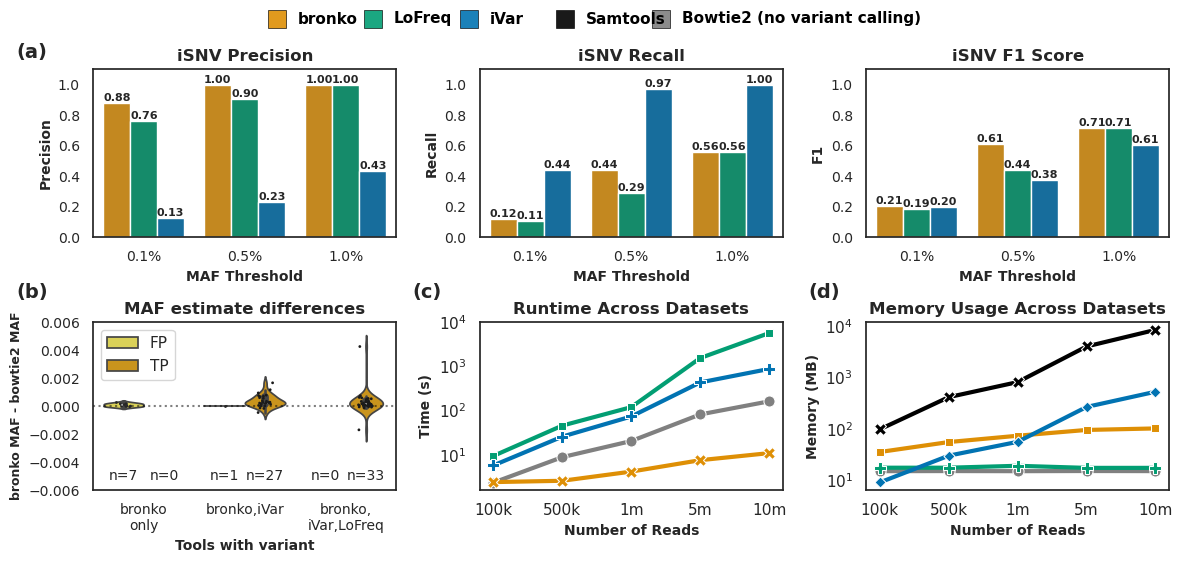

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from matplotlib.patches import Rectangle

# ------------- 1️⃣ Precision / Recall / F1 -----------------
def plot_precision_recall_f1_vs_maf(minor_counts_truth, axes):
    maf_thresholds = [0.001, 0.005, 0.01, 0.015]
    tool_order = ['bronko', 'lofreq', 'ivar']
    base_palette = sns.color_palette("colorblind", n_colors=4)
    tmp_palette = [base_palette[1], base_palette[2], base_palette[0]]
    palette = dict(zip(tool_order, tmp_palette))

    precision_results, recall_results = [], []

    for maf in maf_thresholds:
        df_recall = minor_counts_truth[(minor_counts_truth['truth_maf'] > maf)][['tools', 'truth', 'truth_maf']]
        if df_recall.empty:
            continue
        total_truths = len(df_recall)
        df_exploded = df_recall.assign(tool=df_recall['tools'].str.split(',')).explode('tool')
        counts = (
            df_exploded[df_exploded['truth'] == 1]
            .groupby('tool').size().reindex(tool_order, fill_value=0).reset_index(name='TP')
        )
        counts['Recall'] = counts['TP'] / total_truths
        counts['MAF'] = maf
        recall_results.append(counts[['tool', 'Recall', 'MAF']])

        df_prec = minor_counts_truth[
            (minor_counts_truth['bt2_maf'] > maf) | (minor_counts_truth['bronko_maf'] > maf)
        ][['tools', 'truth']]
        if df_prec.empty:
            continue
        df_exploded = df_prec.assign(tool=df_prec['tools'].str.split(',')).explode('tool')
        counts = df_exploded.groupby(['truth', 'tool']).size().reset_index(name='count')
        counts['truth'] = counts['truth'].map({1: 'True Positives', 0: 'False Positives'})
        precision_df = counts.pivot(index='tool', columns='truth', values='count').fillna(0)
        for col in ['True Positives', 'False Positives']:
            if col not in precision_df.columns:
                precision_df[col] = 0
        precision_df['Precision'] = precision_df.apply(
            lambda x: x['True Positives'] / (x['True Positives'] + x['False Positives'])
            if (x['True Positives'] + x['False Positives']) > 0 else 0, axis=1
        )
        precision_df = precision_df.reset_index()
        precision_df['MAF'] = maf
        precision_results.append(precision_df[['tool', 'Precision', 'MAF']])

    precision_all = pd.concat(precision_results)
    recall_all = pd.concat(recall_results)
    merged = pd.merge(precision_all, recall_all, on=['tool', 'MAF'])
    merged['F1'] = 2 * (merged['Precision'] * merged['Recall']) / (merged['Precision'] + merged['Recall'])

    metrics = ['Precision', 'Recall', 'F1']
    titles = ['iSNV Precision', 'iSNV Recall', 'iSNV F1 Score']

    for ax, metric, title in zip(axes, metrics, titles):
        sns.barplot(data=merged, x='MAF', y=metric, hue='tool',
                    palette=palette, hue_order=tool_order, ax=ax)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1.1)
        ax.set_ylabel(metric, fontsize=10, fontweight='bold')
        ax.set_xlabel('MAF Threshold', fontsize=10, fontweight='bold')
        ax.set_xticklabels([f"{maf*100}%" for maf in maf_thresholds])
        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)
        ax.get_legend().remove()
        
        for container in ax.containers:
            ax.bar_label(container, label_type='edge', fmt="%.2f", fontweight='bold', fontsize=8)
            
    return merged


# ------------- 2️⃣ Bronko violin plot -----------------
def plot_bronko_violin(ax, bronko_vars):
    bronko_vars['maf difference'] = bronko_vars['bronko_maf'] - bronko_vars['bt2_maf']
    counts = (
        bronko_vars.groupby(["tools", "truth"])
          .size()
          .reset_index(name="n")
          .pivot(index="tools", columns="truth", values="n")
          .fillna(0)
    )
    palette = {1: "#E69F00", 0: "#F0E442"}
    order = ['bronko', 'bronko,ivar', 'bronko,ivar,lofreq']

    sns.violinplot(data=bronko_vars, x="tools", order=order, y="maf difference",
                   hue="truth", palette=palette, ax=ax)
    sns.stripplot(data=bronko_vars, x="tools", y="maf difference", hue="truth",
                  order=order, dodge=True, jitter=0.15, size=2, color="k", ax=ax)
    ax.set_xticklabels(["bronko\nonly", "bronko,iVar", "bronko,\niVar,LoFreq"], fontsize=9)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], ["FP", "TP"])
    for i, tool in enumerate(counts.index):
        for j, truth_val in enumerate(counts.columns):
            n = int(counts.loc[tool, truth_val])
            offset = -0.2 if truth_val == 0 else 0.2
            ax.text(i + offset, -0.0045, f"n={n}", ha="center", va="top", fontsize=10)
    ax.axhline(0, color="black", alpha=0.5, linestyle=':')
    ax.set_ylim(-0.006, 0.006)
    ax.set_ylabel("bronko MAF - bowtie2 MAF", fontsize=9, fontweight='bold')
    ax.set_xlabel("Tools with variant", fontsize=10, fontweight='bold')
    ax.set_title("MAF estimate differences", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)


# ------------- 3️⃣ Runtime plot -----------------
def plot_times_across_folders(folder_list, ax):
    col_to_tool = {
        "BT2_Time": "bowtie2 (no variant calling)",
        "BT2_LoFreq_Time": "lofreq",
        "BT2_iVar_Time": "ivar",
        "Bronko_Time": "bronko"
    }
    tool_order = ["bowtie2 (no variant calling)", "bronko", "lofreq", "ivar"]
    base_palette = sns.color_palette("colorblind", n_colors=4)
    tmp_palette = ["gray", base_palette[1], base_palette[2], base_palette[0]]
    palette = dict(zip(tool_order, tmp_palette))

    rows = []
    for folder in folder_list:
        path = os.path.join(folder, "sample_1/overview.tsv")
        if not os.path.exists(path):
            continue
        df = pd.read_csv(path, sep="\t")
        entry = {"folder": folder}
        for col in col_to_tool:
            entry[col] = pd.to_numeric(df.get(col, [pd.NA]).iloc[0], errors="coerce")
        rows.append(entry)

    if not rows: return
    combined = pd.DataFrame(rows)
    df_long = combined.melt(id_vars="folder", value_vars=list(col_to_tool.keys()),
                            var_name="col", value_name="Time")
    df_long["Tool"] = df_long["col"].map(col_to_tool)
    df_long = df_long.dropna(subset=["Time"])
    df_long["folder"] = pd.Categorical(df_long["folder"], categories=folder_list, ordered=True)
    df_long["Tool"] = pd.Categorical(df_long["Tool"], categories=tool_order, ordered=True)

    sns.lineplot(data=df_long, x="folder", y="Time", hue="Tool", style="Tool",
                 markers=True, dashes=False, palette=palette, ax=ax, linewidth=3, markersize=8)
    ax.set_title("Runtime Across Datasets", fontsize=12, fontweight="bold")
    ax.set_xlabel("Number of Reads", fontsize=10, fontweight="bold")
    ax.set_xticklabels(["100k", "500k", "1m", "5m", "10m"])
    ax.set_ylabel("Time (s)", fontsize=10, fontweight="bold")
    ax.set_yscale("log")
    ax.set_ylim(0, 10000)
    ax.get_legend().remove()


# ------------- 4️⃣ Memory plot -----------------
def plot_memory_across_folders(folder_list, ax):
    col_to_tool = {
        "BT2_Mem": "bowtie2 (no variant calling)",
        "Samtools_Mem": "samtools", 
        "BT2_LoFreq_Mem": "lofreq",
        "BT2_iVar_Mem": "ivar",
        "Bronko_Mem": "bronko"
    }
    tool_order = ["bowtie2 (no variant calling)", "samtools", "bronko", "lofreq", "ivar"]
    base_palette = sns.color_palette("colorblind", n_colors=4)
    tmp_palette = ["gray", "black", base_palette[1], base_palette[2], base_palette[0]]
    palette = dict(zip(tool_order, tmp_palette))

    rows = []
    for folder in folder_list:
        path = os.path.join(folder, "sample_1/overview.tsv")
        if not os.path.exists(path):
            continue
        df = pd.read_csv(path, sep="\t")
        entry = {"folder": folder}
        for col in col_to_tool:
            entry[col] = pd.to_numeric(df.get(col, [pd.NA]).iloc[0], errors="coerce")
        rows.append(entry)
    if not rows: return

    combined = pd.DataFrame(rows)
    df_long = combined.melt(id_vars="folder", value_vars=list(col_to_tool.keys()),
                            var_name="col", value_name="Time")
    df_long["Tool"] = df_long["col"].map(col_to_tool)
    df_long = df_long.dropna(subset=["Time"])
    df_long["folder"] = pd.Categorical(df_long["folder"], categories=folder_list, ordered=True)
    df_long["Tool"] = pd.Categorical(df_long["Tool"], categories=tool_order, ordered=True)

    sns.lineplot(data=df_long, x="folder", y="Time", hue="Tool", style="Tool",
                 markers=True, dashes=False, palette=palette, ax=ax, linewidth=3, markersize=8)
    ax.set_title("Memory Usage Across Datasets", fontsize=12, fontweight="bold")
    ax.set_xlabel("Number of Reads", fontsize=10, fontweight="bold")
    ax.set_xticklabels(["100k", "500k", "1m", "5m", "10m"])
    ax.set_ylabel("Memory (MB)", fontsize=10, fontweight="bold")
    ax.set_yscale("log")
    ax.get_legend().remove()


# ------------- Combine all -----------------
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
sns.set_theme(style="white")

# top row: precision/recall/F1
plot_precision_recall_f1_vs_maf(minor_all, axes[0])

# bottom row: violin, runtime, memory
bronko_vars = minor_all[(~minor_all['tools'].isna()) & (minor_all['tools'].str.contains('bronko'))]
plot_bronko_violin(axes[1, 0], bronko_vars)
plot_times_across_folders(['100k_reads', '500k_reads', '1m_reads', '5m_reads', '10m_reads'], axes[1, 1])
plot_memory_across_folders(['100k_reads_mem', '500k_reads_mem', '1m_reads_mem', '5m_reads_mem', '10m_reads_mem'], axes[1, 2])

labels = ["bronko", "LoFreq", "iVar", "Samtools", "Bowtie2 (no variant calling)"]

# Same colors as runtime plot
base_palette = sns.color_palette("colorblind", n_colors=4)
colors = [base_palette[1], base_palette[2], base_palette[0], "black", "gray"]

# Create uniform color boxes and text above figure
y = 0.92           # vertical position in figure coords
x_start = 0.23     # where first label starts
x_step = 0.1      # spacing between labels

box_w, box_h = 0.015, 0.03  # size of each color box (in figure coords)

for i, (label, color) in enumerate(zip(labels, colors)):
    if i == 3:
        x_step = 0.08
    else:
        x_step = 0.1
    x = x_start + i * x_step
    # draw box
    fig.patches.append(Rectangle(
        (x, y - box_h / 2), box_w, box_h,
        transform=fig.transFigure,
        facecolor=color, edgecolor='black', lw=0.5, alpha=0.9
    ))
    # add text next to it
    fig.text(x + box_w + 0.01, y, label,
             ha='left', va='center', fontsize=11, fontweight='bold', color='black')

# Adjust layout to leave room
fig.text(0.02, 0.88, '(a)', fontsize=14, fontweight='bold', ha='left', va='top')  # top-left figure
fig.text(0.02, 0.48, '(b)', fontsize=14, fontweight='bold', ha='left', va='top')  # bottom-left
fig.text(0.35, 0.48, '(c)', fontsize=14, fontweight='bold', ha='left', va='top')  # bottom-middle
fig.text(0.68, 0.48, '(d)', fontsize=14, fontweight='bold', ha='left', va='top')  # bottom-right
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("../figures/Fig2.pdf", bbox_inches="tight", dpi=600)
plt.savefig("../figures/Fig2.svg", bbox_inches="tight", dpi=600)
plt.savefig("../figures/Fig2.png", bbox_inches="tight", dpi=600)
plt.show()